In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Configuration
RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3"
BASE_PATH = Path("../experiments/shap_outputs") / RUN_NAME
ALPHA = 0.3  # EWMA smoothing factor (higher = more weight on recent values)

print("✓ Configuration loaded")
print(f"  Run: {RUN_NAME}")
print(f"  Path: {BASE_PATH}")
print(f"  EWMA alpha: {ALPHA}")

✓ Configuration loaded
  Run: fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3
  Path: ../experiments/shap_outputs/fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3
  EWMA alpha: 0.3


In [10]:
def load_metadata(metadata_path):
    """Load metadata from a client directory."""
    try:
        with open(metadata_path, "r") as f:
            return json.load(f)
    except:
        return {}


def load_shap_values(shap_path):
    """Load SHAP values from npz file."""
    try:
        data = np.load(shap_path, allow_pickle=True)
        # SHAP values typically stored as 'values' or similar
        keys = list(data.keys())
        if len(keys) > 0:
            return data[keys[0]]
        return None
    except:
        return None


def compute_stability_score(shap_ref, shap_curr):
    """
    Compute stability score between the current SHAP vector and a moving-average reference.
    High score = stable (honest behavior)
    Low score = unstable (suspicious behavior)
    """
    if shap_ref is None or shap_curr is None:
        return None

    v_ref = shap_ref.flatten()
    v_i = shap_curr.flatten()

    num = np.linalg.norm(v_i - v_ref)
    denom = np.linalg.norm(v_ref) + 0.05

    return 1 - num / denom
    # # Cosine similarity:
    # norm1 = np.linalg.norm(v1)
    # norm2 = np.linalg.norm(v2)

    # if norm1 < 1e-10 or norm2 < 1e-10:
    #     return 1.0

    # similarity = np.dot(v1, v2) / (norm1 * norm2)
    # # Clamp to [0, 1]
    # return max(0, min(1, (similarity + 1) / 2))


print("✓ Helper functions defined")

✓ Helper functions defined


In [11]:
# Load data for all clients across all rounds
client_data = defaultdict(dict)
round_dirs = sorted(
    [d for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")]
)

print(f"Loading data from {len(round_dirs)} rounds...")

for round_dir in round_dirs:
    round_num = int(round_dir.name.split("_")[1])
    client_dirs = sorted(
        [d for d in round_dir.iterdir() if d.is_dir() and d.name.startswith("client_")]
    )

    for client_dir in client_dirs:
        client_id = client_dir.name

        # Load metadata
        metadata_path = client_dir / "metadata.json"
        metadata = load_metadata(metadata_path)

        # Load SHAP values
        shap_path = client_dir / "shap_values.npz"
        shap_values = load_shap_values(shap_path)

        # Store data
        if client_id not in client_data:
            client_data[client_id] = {
                "is_malicious": metadata.get(
                    "malicious", metadata.get("is_malicious", False)
                ),
                "rounds": {},
            }

        client_data[client_id]["rounds"][round_num] = {
            "shap": shap_values,
            "metadata": metadata,
        }

print(f"✓ Loaded data for {len(client_data)} clients")
print(f"  Sample client: {list(client_data.keys())[0]}")
print(f"  Malicious: {sum(1 for c in client_data.values() if c['is_malicious'])}")
print(f"  Honest: {sum(1 for c in client_data.values() if not c['is_malicious'])}")

Loading data from 22 rounds...
✓ Loaded data for 30 clients
  Sample client: client_1
  Malicious: 6
  Honest: 24


In [12]:
# Compute round-by-round stability scores
scores_data = []

for client_id, client_info in client_data.items():
    rounds = sorted(client_info["rounds"].keys())
    shap_ref = None

    for round_num in rounds:
        shap_curr = client_info["rounds"][round_num]["shap"]

        # Compute stability score vs the moving-average reference from previous rounds
        if shap_ref is not None:
            stability = compute_stability_score(shap_ref, shap_curr)
        else:
            stability = None  # No score for first round

        scores_data.append(
            {
                "client": client_id,
                "round": round_num,
                "stability": stability,
                "is_malicious": client_info["is_malicious"],
            }
        )

        if shap_ref is None:
            shap_ref = shap_curr.astype(float).copy()
        else:
            shap_ref = ALPHA * shap_curr + (1 - ALPHA) * shap_ref

# Convert to DataFrame for easier analysis
df_scores = pd.DataFrame(scores_data)
df_scores = df_scores[df_scores["stability"].notna()]  # Remove None values

print(f"✓ Computed {len(df_scores)} stability scores")
print("\nStability Score Statistics:")
print(df_scores.groupby("is_malicious")["stability"].describe())

✓ Computed 629 stability scores

Stability Score Statistics:
              count      mean       std       min       25%       50%  \
is_malicious                                                            
False         504.0  0.680972  0.198343 -0.397424  0.639829  0.739274   
True          125.0  0.376190  0.476750 -1.929951  0.213075  0.539985   

                   75%       max  
is_malicious                      
False         0.795323  0.862617  
True          0.712874  0.823836  


In [13]:
def compute_prev_round_similarity(shap_prev, shap_curr):
    if shap_prev is None or shap_curr is None:
        return None

    v_prev = shap_prev.flatten()
    v_curr = shap_curr.flatten()

    num = np.linalg.norm(v_curr - v_prev)
    denom = np.linalg.norm(v_prev) + 0.05
    return 1 - num / denom


comparison_data = []

for client_id, client_info in client_data.items():
    rounds = sorted(client_info["rounds"].keys())
    shap_ref = None

    for i, round_num in enumerate(rounds):
        shap_curr = client_info["rounds"][round_num]["shap"]

        if i > 0:
            shap_prev = client_info["rounds"][rounds[i - 1]]["shap"]
            prev_round_sim = compute_prev_round_similarity(shap_prev, shap_curr)
        else:
            prev_round_sim = None

        if shap_ref is not None:
            ref_sim = compute_stability_score(shap_ref, shap_curr)
        else:
            ref_sim = None

        comparison_data.append(
            {
                "client": client_id,
                "round": round_num,
                "prev_round_sim": prev_round_sim,
                "ref_sim": ref_sim,
                "is_malicious": client_info["is_malicious"],
            }
        )

        if shap_ref is None:
            shap_ref = shap_curr.astype(float).copy()
        else:
            shap_ref = ALPHA * shap_curr + (1 - ALPHA) * shap_ref

df_comparison = pd.DataFrame(comparison_data).dropna()

print(f"✓ Computed {len(df_comparison)} comparison scores")
print("\nMean similarity by class:")
print(df_comparison.groupby("is_malicious")[["prev_round_sim", "ref_sim"]].mean())
print("\nMean difference (prev_round_sim - ref_sim):")
print(
    df_comparison.assign(
        diff=df_comparison["prev_round_sim"] - df_comparison["ref_sim"]
    )
    .groupby("is_malicious")["diff"]
    .mean()
)

✓ Computed 629 comparison scores

Mean similarity by class:
              prev_round_sim   ref_sim
is_malicious                          
False               0.665205  0.680972
True                0.483568  0.376190

Mean difference (prev_round_sim - ref_sim):
is_malicious
False   -0.015767
True     0.107378
Name: diff, dtype: float64


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.lines import Line2D

# --- Per-round threshold (ZTA-FL paper implementation) ---
# For each round: compute mu_s and sigma_s across all clients,
# flag any client whose stability < mu_s - 2*sigma_s in that round.

df_detection = df_comparison.copy()

# Per-round mu and sigma
round_stats = (
    df_detection.groupby("round")["ref_sim"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "round_mu", "std": "round_sigma"})
    .reset_index()
)
df_detection = df_detection.merge(round_stats, on="round")
df_detection["threshold"] = df_detection["round_mu"] - 2 * df_detection["round_sigma"]
df_detection["flagged"] = df_detection["ref_sim"] < df_detection["threshold"]

print("Per-round thresholds:")
print(
    round_stats.assign(
        threshold=round_stats["round_mu"] - 2 * round_stats["round_sigma"]
    ).to_string(index=False)
)

Per-round thresholds:
 round  round_mu  round_sigma  threshold
     2  0.351608     0.650610  -0.949612
     3  0.377215     0.459852  -0.542489
     4  0.516087     0.292895  -0.069703
     5  0.588566     0.182916   0.222734
     6  0.515195     0.384944  -0.254693
     7  0.621384     0.193541   0.234303
     8  0.678208     0.120182   0.437845
     9  0.532990     0.411344  -0.289698
    10  0.636380     0.217896   0.200588
    11  0.701092     0.135848   0.429396
    12  0.636481     0.334575  -0.032669
    13  0.703926     0.204532   0.294863
    14  0.742862     0.131619   0.479624
    15  0.659463     0.248882   0.161699
    16  0.735488     0.089052   0.557384
    17  0.673490     0.249839   0.173812
    18  0.586916     0.338853  -0.090790
    19  0.657533     0.254528   0.148478
    20  0.714692     0.110767   0.493159
    21  0.663529     0.187583   0.288363
    22  0.739327     0.092611   0.554104


In [15]:
# --- Aggregate flags to client level ---
label_map = {cid: info["is_malicious"] for cid, info in client_data.items()}

client_flags = (
    df_detection.groupby("client")["flagged"]
    .agg(flag_rate="mean", n_flagged="sum", n_rounds="count")
    .reset_index()
)
client_flags["is_malicious"] = client_flags["client"].map(label_map)

# Two natural decision rules:
# (a) flagged in ANY round  -> predicted malicious
# (b) flagged in MAJORITY of rounds -> predicted malicious
client_flags["pred_any"] = client_flags["n_flagged"] >= 1
client_flags["pred_majority"] = client_flags["flag_rate"] >= 0.5

y_true = client_flags["is_malicious"].astype(int).values

for rule, col in [
    ("ANY round flagged", "pred_any"),
    ("MAJORITY of rounds flagged", "pred_majority"),
]:
    print(f"\n=== Decision rule: {rule} ===")
    y_pred = client_flags[col].astype(int).values
    print(classification_report(y_true, y_pred, target_names=["benign", "malicious"]))
    cm = confusion_matrix(y_true, y_pred)
    print(
        pd.DataFrame(
            cm,
            index=["true_benign", "true_malicious"],
            columns=["pred_benign", "pred_malicious"],
        )
    )


=== Decision rule: ANY round flagged ===
              precision    recall  f1-score   support

      benign       0.91      0.83      0.87        24
   malicious       0.50      0.67      0.57         6

    accuracy                           0.80        30
   macro avg       0.70      0.75      0.72        30
weighted avg       0.83      0.80      0.81        30

                pred_benign  pred_malicious
true_benign              20               4
true_malicious            2               4

=== Decision rule: MAJORITY of rounds flagged ===
              precision    recall  f1-score   support

      benign       0.83      1.00      0.91        24
   malicious       1.00      0.17      0.29         6

    accuracy                           0.83        30
   macro avg       0.91      0.58      0.60        30
weighted avg       0.86      0.83      0.78        30

                pred_benign  pred_malicious
true_benign              24               0
true_malicious            5      

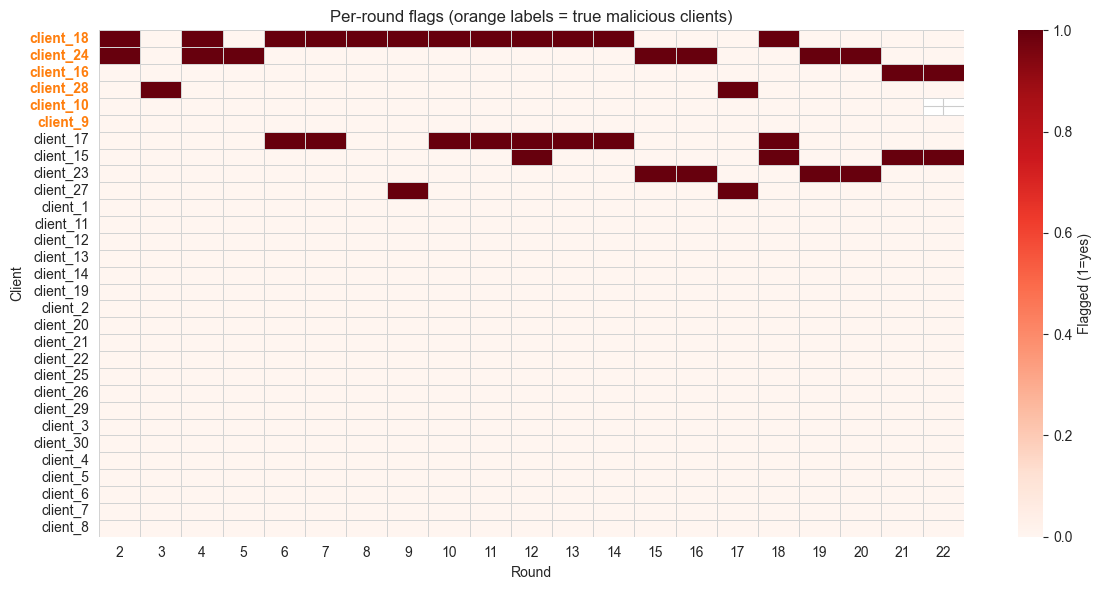

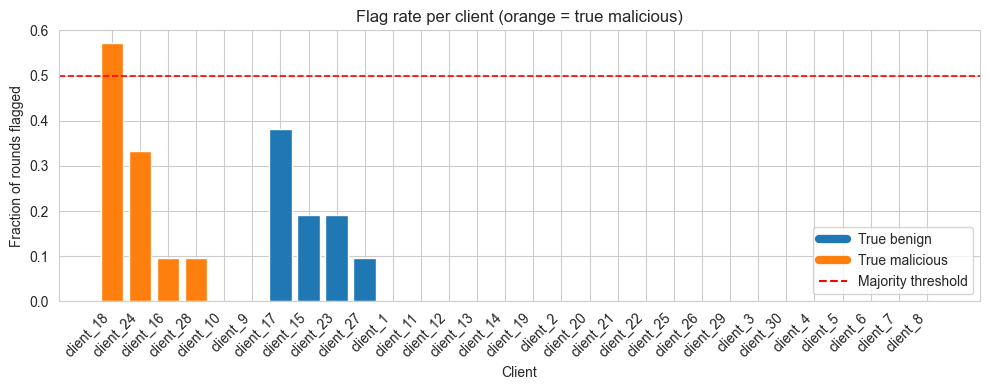

In [16]:
# --- Plot 1: heatmap of per-client, per-round flag status ---
pivot = df_detection.pivot(index="client", columns="round", values="flagged").astype(
    float
)
# Sort rows: malicious clients first
order = client_flags.sort_values(
    ["is_malicious", "flag_rate"], ascending=[False, False]
)["client"]
pivot = pivot.loc[order]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="Reds",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Flagged (1=yes)"},
    vmin=0,
    vmax=1,
)
# Mark malicious clients on y-axis
for i, cid in enumerate(order):
    if label_map[cid]:
        ax.get_yticklabels()[i].set_color("tab:orange")
        ax.get_yticklabels()[i].set_fontweight("bold")
ax.set_title("Per-round flags (orange labels = true malicious clients)")
ax.set_xlabel("Round")
ax.set_ylabel("Client")
plt.tight_layout()
plt.show()

# --- Plot 2: flag rate per client ---
fig, ax = plt.subplots(figsize=(10, 4))
colors = (
    client_flags.set_index("client")
    .loc[order, "is_malicious"]
    .map({True: "tab:orange", False: "tab:blue"})
)
flag_rates = client_flags.set_index("client").loc[order, "flag_rate"]
ax.bar(order, flag_rates, color=colors.values)
ax.axhline(
    0.5, color="red", linestyle="--", linewidth=1.2, label="Majority threshold (0.5)"
)
ax.set_xlabel("Client")
ax.set_ylabel("Fraction of rounds flagged")
ax.set_title("Flag rate per client (orange = true malicious)")
legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=6, label="True benign"),
    Line2D([0], [0], color="tab:orange", linewidth=6, label="True malicious"),
    Line2D([0], [0], color="red", linestyle="--", label="Majority threshold"),
]
ax.legend(handles=legend_elements)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()